## Holt winter's Exponential Smoothing (HWES)

       Symbol Series         Date  PrevClose  OpenPrice  HighPrice  LowPrice  \
0  TATACOFFEE     EQ  05-Jan-2022     217.80     218.50      218.7    214.30   
1  TATACOFFEE     EQ  04-Jan-2022     214.05     214.90      220.8    212.45   
2  TATACOFFEE     EQ  03-Jan-2022     213.15     213.95      216.9    212.30   
3  TATACOFFEE     EQ  31-Dec-2021     208.50     208.90      216.2    208.40   
4  TATACOFFEE     EQ  30-Dec-2021     211.35     211.45      211.5    207.90   

   LastPrice  ClosePrice  AveragePrice TotalTradedQuantity        Turnover₹  \
0     214.65      214.85        215.72           13,50,483  29,13,25,687.40   
1     217.40      217.80        217.41           34,77,443  75,60,37,979.15   
2     214.30      214.05        214.76           15,25,259  32,75,66,528.25   
3     213.70      213.15        213.37           30,45,699  64,98,54,073.20   
4     208.80      208.50        209.36            9,77,484  20,46,47,553.50   

  No.ofTrades  
0      12,079  
1      28,87

C:\Anaconda\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


RMSE-Testset: 0.12289760132558226
maPe-Testset: 37356317691994.52


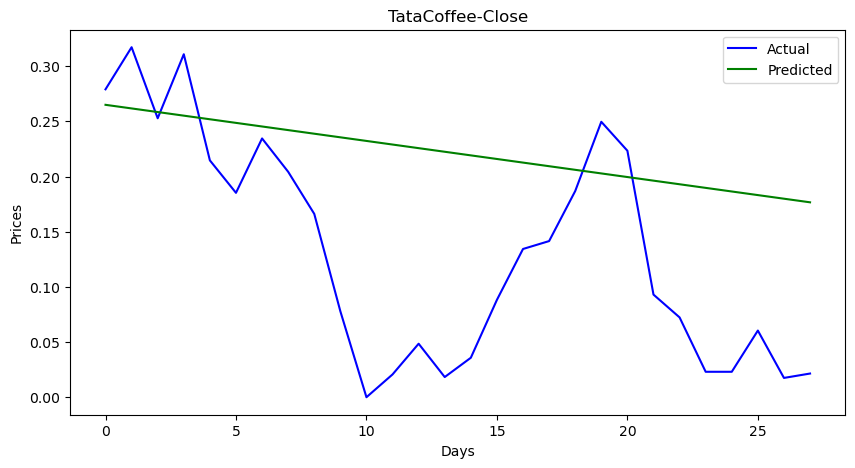

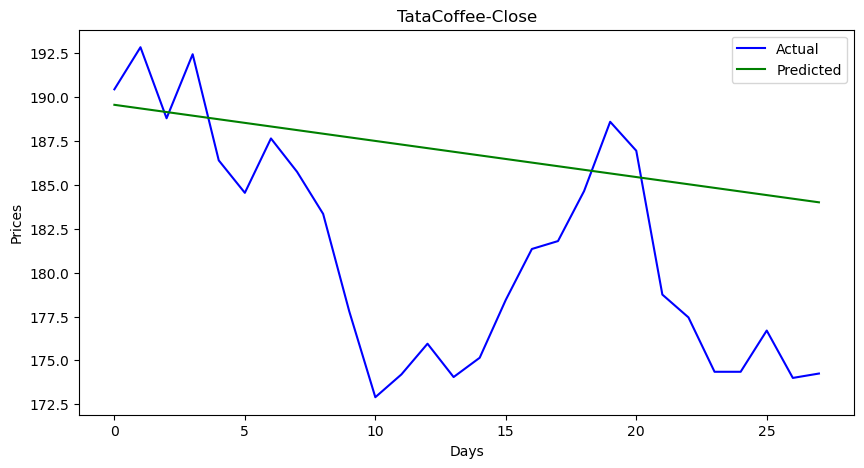

RMSE-Testset: 7.730259123379122
maPe-Testset: 0.03640037948004745
Future Forecast (Scaled):
151    0.016956
152    0.012639
dtype: float64
Forecast in Original Scale:
    Closefore
0  173.966509
1  173.695004


C:\Anaconda\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [1]:
import pandas as pd
from nselib import capital_market as cm

# Define dates
start_date = '01-06-2021'
end_date = '05-01-2022'

# Get stock data
stk_data = cm.price_volume_data(symbol='TATACOFFEE', from_date=start_date, to_date=end_date)
print(stk_data.head())

# Keep only required columns
stk_data = stk_data[["OpenPrice", "HighPrice", "LowPrice", "ClosePrice"]]

# Select target column
column = "ClosePrice"

# Scale only selected column
from sklearn.preprocessing import MinMaxScaler
Ms = MinMaxScaler()
data1 = Ms.fit_transform(stk_data[[column]])
data1 = pd.DataFrame(data1, columns=[column])

print("Len:", data1.shape)

# Train-test split
test_obs = 28
train = data1[:-test_obs]
test = data1[-test_obs:]

# Fit HWES model
from statsmodels.tsa.holtwinters import ExponentialSmoothing
model = ExponentialSmoothing(
    train[column],
    trend='add',
    seasonal=None
)
model_fit = model.fit(optimized=True)

# Forecast test period
y_pred = model_fit.forecast(test_obs)

# Convert normalized actual and predicted values
from stockFunctions import conversionSingle
test_df = conversionSingle(test.values, [column])
pred_df = conversionSingle(y_pred.values, [column])

# Evaluate on normalized scale
from stockFunctions import rmsemape
rmsemape(test_df, pred_df)

# Plot normalized scale
from stockFunctions import graph
graph(test_df, pred_df, "Actual", "Predicted", "TataCoffee-Close", "Days", "Prices")

# Convert actual test to original scale
actual_stock_price_test_ori = Ms.inverse_transform(test_df)
actual_stock_price_test_oriA = conversionSingle(actual_stock_price_test_ori, [column])

# Convert predicted test to original scale
predicted_stock_price_test_ori = Ms.inverse_transform(pred_df)
predicted_stock_price_test_oriP = conversionSingle(predicted_stock_price_test_ori, [column])

# Plot original scale
graph(
    actual_stock_price_test_oriA,
    predicted_stock_price_test_oriP,
    "Actual",
    "Predicted",
    "TataCoffee-Close",
    "Days",
    "Prices"
)

# Evaluate on original scale
rmsemape(actual_stock_price_test_oriA, predicted_stock_price_test_oriP)

# Forecast next 2 future values after full training
full_model = ExponentialSmoothing(
    data1[column],
    trend='add',
    seasonal=None
)
full_model_fit = full_model.fit(optimized=True)

forecast = full_model_fit.forecast(2)
print("Future Forecast (Scaled):")
print(forecast)

# Convert forecast to DataFrame
fTestNormTable = conversionSingle(forecast.values, ["Closefore"])
fTestNormTable.columns = [column]

# Inverse transform
forecast_stock_price_test_ori = Ms.inverse_transform(fTestNormTable)
forecast_stock_price_test_oriF = conversionSingle(forecast_stock_price_test_ori, ["Closefore"])

# Save forecast
forecast_stock_price_test_oriF.to_csv("Closehwes.csv", index=False)

print("Forecast in Original Scale:")
print(forecast_stock_price_test_oriF)
